In [1]:
# Imports
import sys
from pathlib import Path

# This notebook only orchestrates. Every function and class it calls lives in the
# `macrocircuits` package under src/ -- read or edit it there.
SRC = str(Path.cwd().parent / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import matplotlib.pyplot as plt
from IPython.display import display

# Importing macrocircuits also registers this repo's swimmer tasks -- `swim`,
# `swim_12_links`, `swim_to_ball`, `foraging` and `evasion` -- with the dm_control
# swimmer suite, which is what lets suite.load() find them below.
# test_dm_control just steps an environment with random actions and renders it, which
# is all the sanity check below needs.
from dm_control import suite
from macrocircuits import ensure_tonic, test_dm_control

# Clone neuromatch/tonic next to this notebook (once) and put it on the import path.
# It has to run before the tonic-backed imports below (training, models); see
# src/macrocircuits/tonic_setup.py for why tonic isn't a pip install.
ensure_tonic()

# The Swim task rewards swimming forward at _SWIM_SPEED and hides the target the
# stock dm_control swimmer chases. resolve_runs/run_config/run_path turn the runs
# declared in Section 1 into the code strings train() needs and the paths it writes.
# is_trained lets the training cell skip a run whose exact parameters were already
# trained, instead of overwriting its checkpoints.
from macrocircuits.training import (  # See src/macrocircuits/training.py.
    is_trained,
    play_model,
    resolve_runs,
    run_config,
    run_path,
    train,
)
# The Evolution Strategies path -- method='es' below. It is a separate trainer, not a
# tonic agent, so it has its own config/train/play trio. See src/macrocircuits/es.py.
# is_es_trained is its counterpart to is_trained.
from macrocircuits.es import (
    es_config,
    is_es_trained,
    play_es_model,
    run_es,
)
from macrocircuits.plotting import (  # See src/macrocircuits/plotting.py.
    plot_performance,
)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
RUNS = [
    dict(network='ncap', task='foraging', controller='foraging',
               steps=int(1e5), action_noise=0.3, label='ncap_ppo (reflex controller)'),
    dict(network='ncap', task='foraging', controller='naive_piourette_foraging',
           steps=int(1e5), action_noise=0.3, label='ncap_ppo (naive_piourette controller)'),
    dict(network='ncap', task='foraging', controller='mlp_foraging',
                   steps=int(1e5), action_noise=0.3, label='ncap_ppo (mlp controller)'),
]

for run in RUNS:
       agent, environment, name, trainer = run_config(**run)
       train('import tonic.torch', agent, environment, name=name, trainer=trainer)

/home/petron/workshops_conferences_summerschools/Neuromatch_NeuroAI/Projects/neuroai-macrocircuits/.venv/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Config file saved to data/local/experiments/tonic/swimmer-foraging/ncap_ppo (reflex controller)/config.yaml
          Time left:  epoch 0:00:00  total 0:02:21          
actor                                                       
  clip fraction                                      0.00693
  entropy                                              0.215
  iterations                                              80
  kl                                                 0.00194
  loss                                             -0.000844
  std                                                    0.3
  stop                                                     0
critic                                                      
  iterations                                              80
  loss                                                0.0066
  v                                                    0.114
test                                                        
  action                              

/home/petron/workshops_conferences_summerschools/Neuromatch_NeuroAI/Projects/neuroai-macrocircuits/.venv/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Config file saved to data/local/experiments/tonic/swimmer-foraging/ncap_ppo (naive_piourette controller)/config.yaml
          Time left:  epoch 0:00:00  total 0:02:08          
actor                                                       
  clip fraction                                         0.63
  entropy                                              0.215
  iterations                                               1
  kl                                                    1.41
  loss                                                 0.232
  std                                                    0.3
  stop                                                     1
critic                                                      
  iterations                                              80
  loss                                                  0.37
  v                                                    0.305
test                                                        
  action                     

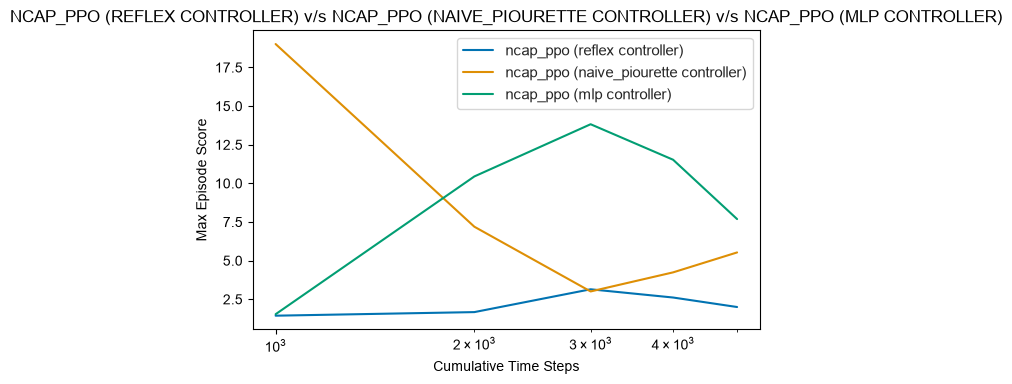

In [3]:
# rerun this cell if it displays more than the graphs
%matplotlib inline

# One panel per environment: the tasks reward different things (forward speed, food
# eaten, obstacles dodged), so their curves do not belong on shared axes.
tasks = list(dict.fromkeys(run['task'] for run in RUNS))
fig, axes = plt.subplots(1, len(tasks), figsize=(6 * len(tasks), 4), squeeze=False)

# Learning curve of every run trained above, from the same RUNS list, so the paths
# always match what the training cell wrote. plot_performance names each curve after
# the last folder of its path -- i.e. the run's label.
for ax, task in zip(axes[0], tasks):
    task_runs = [run for run in RUNS if run['task'] == task]
    # The legend names every curve, so only spell the runs out in the title while they
    # still fit on one line.
    if len(task_runs) <= 3:
        title = ' v/s '.join(run['label'].upper() for run in task_runs)
    else:
        title = f'{len(task_runs)} runs on {task}'
    plot_performance([run_path(**run) for run in task_runs], ax=ax, title=title)

plt.tight_layout()
plt.show()

In [4]:
play_model('data/local/experiments/tonic/swimmer-foraging/ncap_ppo (naive_piourette_foraging)')

/home/petron/workshops_conferences_summerschools/Neuromatch_NeuroAI/Projects/neuroai-macrocircuits/.venv/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")



Loading weights from data/local/experiments/tonic/swimmer-foraging/ncap_ppo (naive_piourette_foraging)/checkpoints/step_100000.pt
Reward for the run:  0.43485633
